<a href="https://colab.research.google.com/github/Nikerlas/MelatihUlar/blob/main/PerbaikanCitraDalamDomainSpasial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#P1. Transormasi Kurva

In [5]:
import numpy as  np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

In [6]:
image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)

negative_gray = 1.0 - image_gray_float

In [7]:
image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)

negative_color = 1.0 - image_color_float

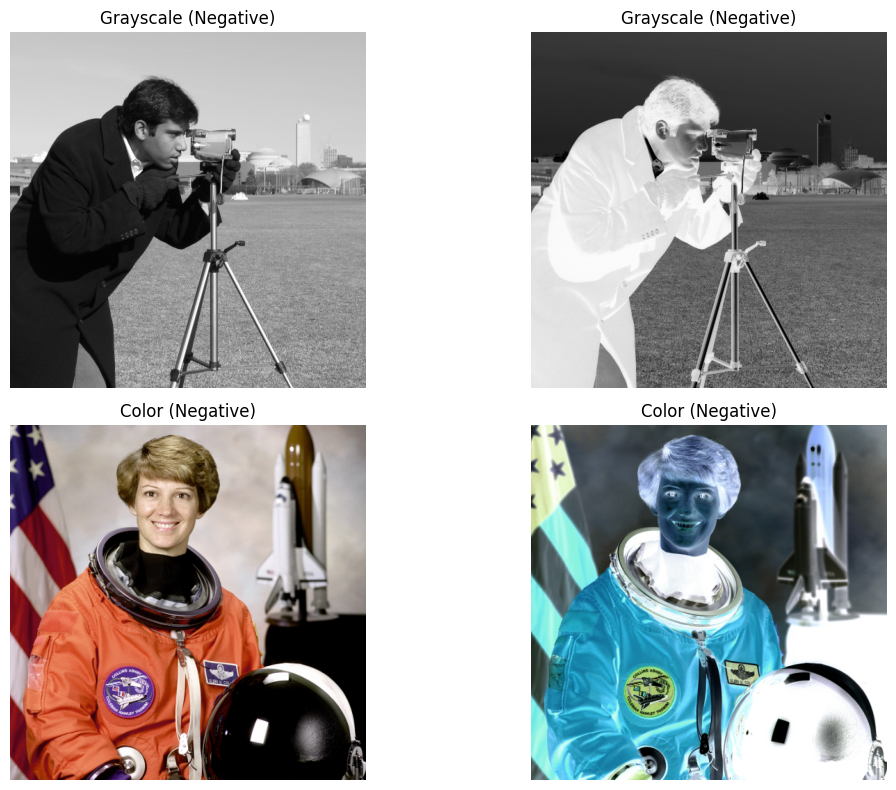

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Negative)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Negative)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

#P2. Histogram dan Ekualisasi Histogram

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

In [10]:
image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)

hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

In [11]:
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

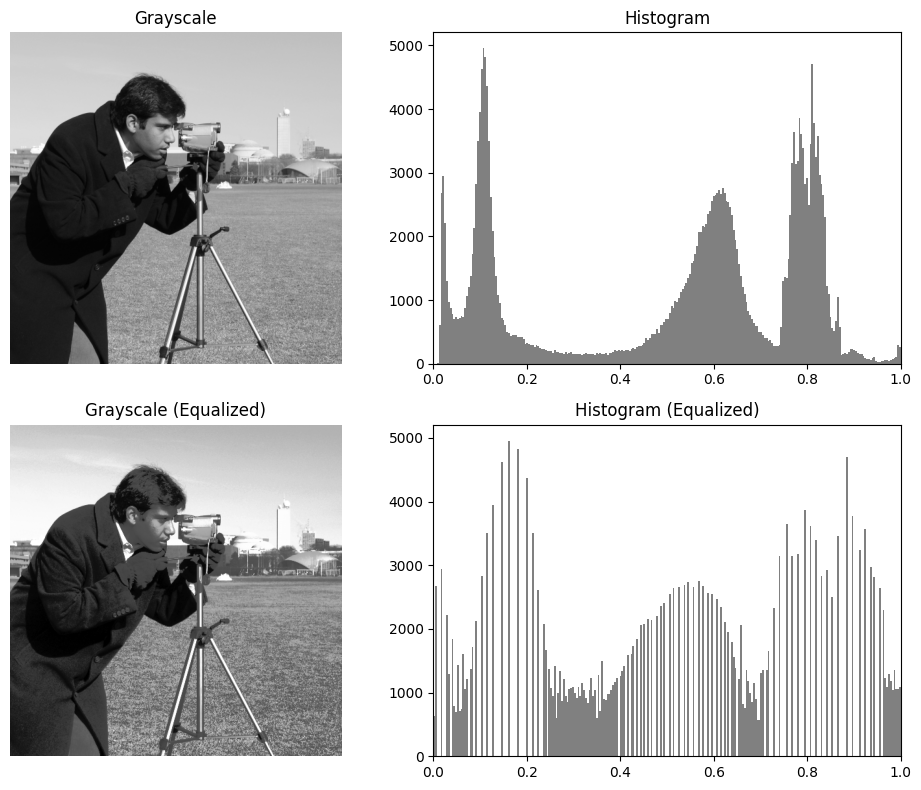

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale")
axes[0, 0].axis('off')

axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram")
axes[0, 1].set_xlim(0,1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale (Equalized)")
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram (Equalized)")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

In [13]:
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

In [14]:
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

In [16]:
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

In [15]:
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

In [17]:
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

In [18]:
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

<ipython-input-21-aa7a16b0223d>:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes2[0, 1].legend(loc='upper right')


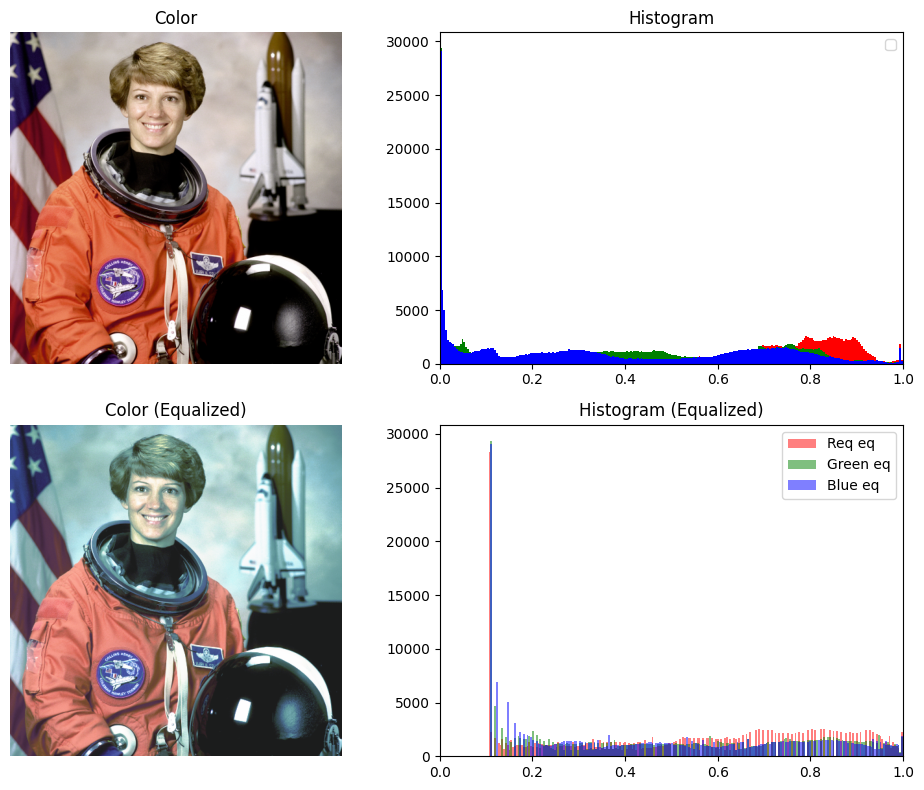

In [21]:
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color")
axes2[0, 0].axis('off')

axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue')

axes2[0, 1].set_title("Histogram")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color (Equalized)")
axes2[1, 0].axis('off')

axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Req eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram (Equalized)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

#P3. Konvolusi

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

In [24]:
gray_uint8 = data.camera()
gray_img = img_as_float(gray_uint8)

In [25]:
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

In [27]:
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

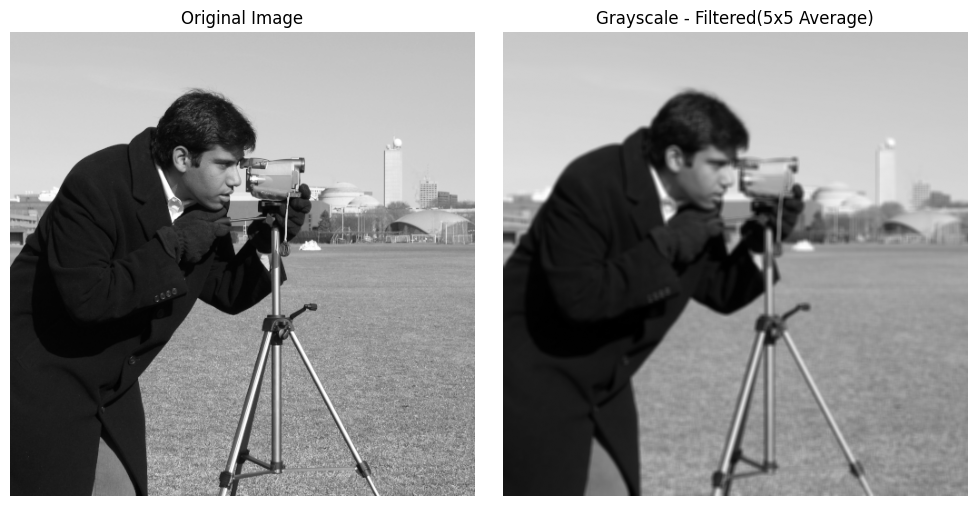

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [30]:
color_uint8 = data.astronaut()
color_img = img_as_float(color_uint8)

In [32]:
color_filtered = np.zeros_like(color_img)

for c in range(3):
  channel_original = color_img[:,:,c]
  channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
  color_filtered[:,:,c] = channel_filtered

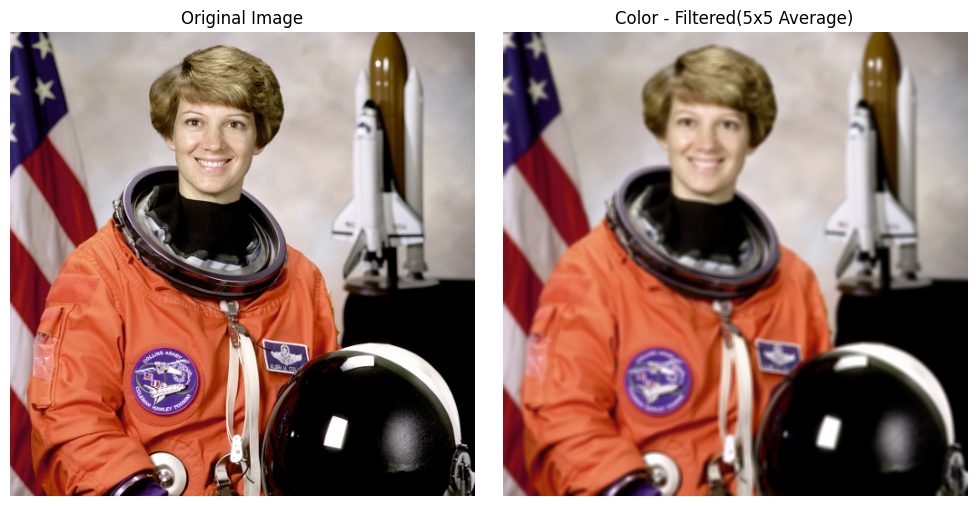

In [34]:
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(color_img)
axes2[0].set_title('Original Image')
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

#P4. Filter Median

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

In [37]:
gray_uint8 = data.camera()
gray_float = img_as_float(gray_uint8)

In [38]:
gray_noisy = util.random_noise(gray_float, mode='gaussian', var=0.05)

In [39]:
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

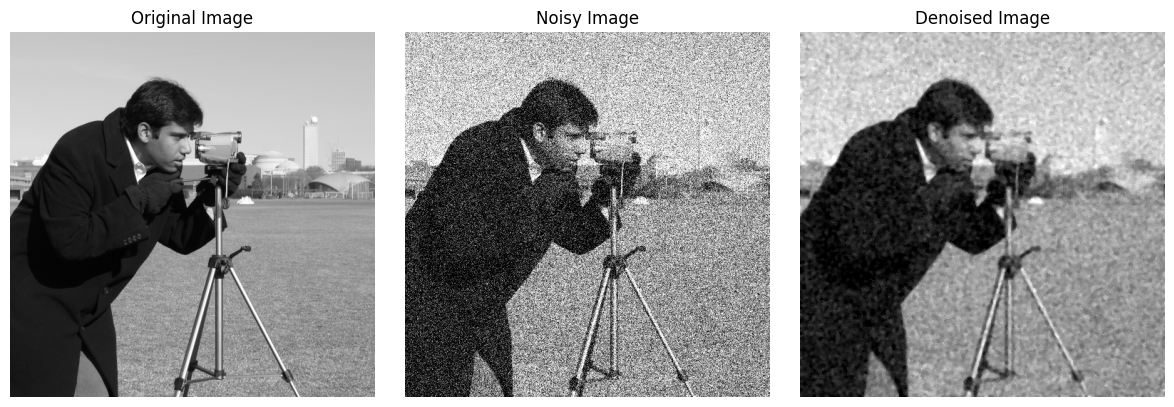

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title('Noisy Image')
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title('Denoised Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [43]:
color_uint8 = data.astronaut()
color_float = img_as_float(color_uint8)

color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

In [45]:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
  color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

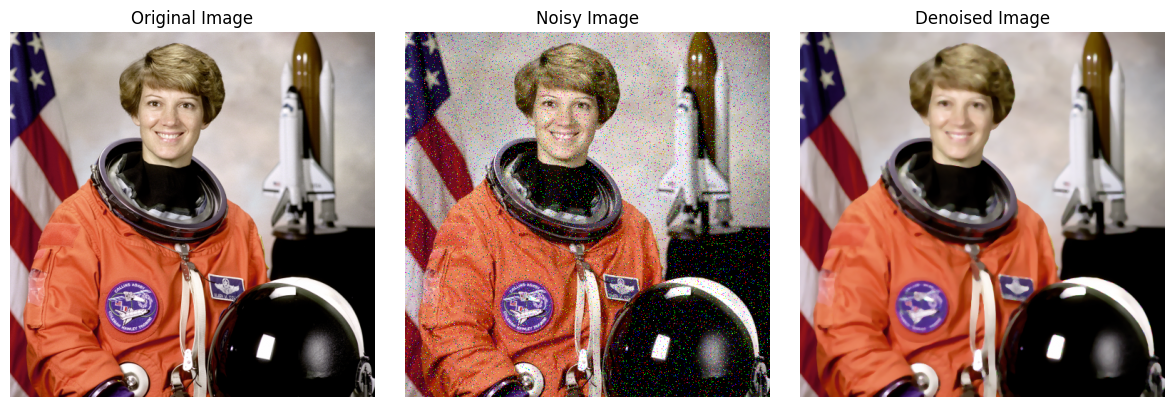

In [46]:
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title('Original Image')
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title('Noisy Image')
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title('Denoised Image')
axes2[2].axis('off')

plt.tight_layout()
plt.show()